# Première lecture des documents FOMC

Point de départ : `data/raw/fomc_documents_raw.csv`.

In [81]:
import os
import re
import tempfile
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "fomc_nlp_matplotlib"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 180)

In [82]:
ROOT = Path.cwd()
if not (ROOT / "data" / "raw" / "fomc_documents_raw.csv").exists():
    ROOT = ROOT.parent

raw_path = ROOT / "data" / "raw" / "fomc_documents_raw.csv"
raw = pd.read_csv(raw_path, parse_dates=["date"])
raw.head(1)

,date,year,meeting_id,statement_url,minutes_url,statement_text,minutes_text,statement_download_error,minutes_download_error
0,2000-02-02,2000,2000-02-02,https://www.federalreserve.gov/boarddocs/press/general/2000/20000202/,https://www.federalreserve.gov/fomc/minutes/20000202.htm,"Release Date: February 2, 2000 For immediate release The Federal Open Market Committee voted today to raise its target for the federal funds rate by 25 basis points to 5-3/4 pe...","Minutes of the Federal Open Market Committee February 1-2, 2000 A meeting of the Federal Open Market Committee was held in the offices of the Board of Governors of the Federal ...",NaN,NaN


Premier aperçu du fichier chargé.

In [83]:
pd.Series({
    "rows": len(raw),
    "first_date": raw["date"].min().date(),
    "last_date": raw["date"].max().date(),
    "duplicated_dates": raw["date"].duplicated().sum(),
    "empty_statements": raw["statement_text"].fillna("").str.len().eq(0).sum(),
    "empty_minutes": raw["minutes_text"].fillna("").str.len().eq(0).sum(),
})

rows                       199
first_date          2000-02-02
last_date           2024-12-18
duplicated_dates             0
empty_statements             0
empty_minutes                0
dtype: object

199 réunions entre 2000 et 2024. Les deux textes sont présents à chaque fois.

Nettoyage : minuscules, espaces propres, comptage de mots par regex.

In [84]:
TOKEN_RE = re.compile(r"[a-z]+(?:'[a-z]+)?", re.IGNORECASE)

def clean_text(text):
    text = "" if pd.isna(text) else str(text)
    text = text.replace(" ", " ")
    text = text.replace("’", "'").replace("‘", "'")
    text = text.replace("“", '"').replace("”", '"')
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def count_words(text):
    return len(TOKEN_RE.findall(clean_text(text)))

df = raw.assign(**{
    "statement_clean_text": raw["statement_text"].map(clean_text),
    "minutes_clean_text": raw["minutes_text"].map(clean_text),
    "statement_n_words": raw["statement_text"].map(count_words),
    "minutes_n_words": raw["minutes_text"].map(count_words),
})

df[["date", "statement_n_words", "minutes_n_words"]].head()

,date,statement_n_words,minutes_n_words
0,2000-02-02,202,8319
1,2000-03-21,208,4434
2,2000-05-16,202,4072
3,2000-06-28,178,4345
4,2000-08-22,181,4208


In [85]:
lengths = pd.concat([
    df[["date", "year", "statement_n_words"]].rename(columns={"statement_n_words": "n_words"}).assign(document_type="statement"),
    df[["date", "year", "minutes_n_words"]].rename(columns={"minutes_n_words": "n_words"}).assign(document_type="minutes"),
], ignore_index=True)

lengths.groupby("document_type")["n_words"].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
document_type,,,,,,,,
minutes,199.0,7283.2,2441.3,3262.0,4870.0,7536.0,8552.5,14505.0
statement,199.0,526.1,217.4,145.0,337.0,536.0,672.0,1078.0


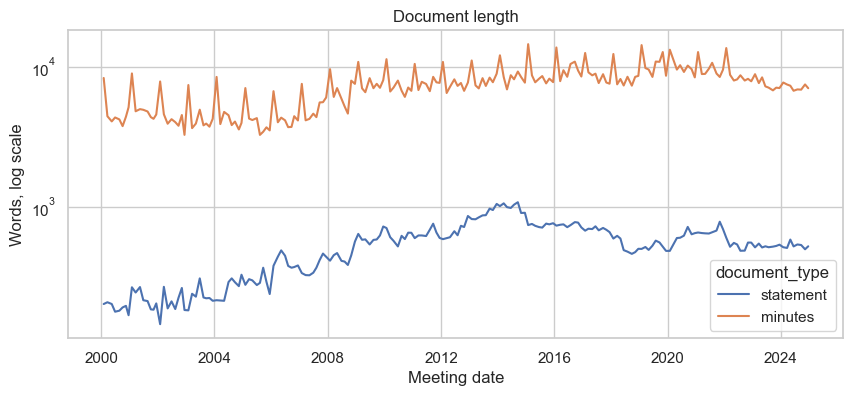

In [86]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=lengths, x="date", y="n_words", hue="document_type", ax=ax)
ax.set_yscale("log")
ax.set_title("Document length")
ax.set_xlabel("Meeting date")
ax.set_ylabel("Words, log scale");

La taille des documents tend à augmenter légèrement dans le temps. Les Minutes sont surtout beaucoup plus longues que les Statements.

Les pics réguliers dans les Minutes viennent en partie des réunions avec projections économiques, qui ajoutent plus de contenu à la publication.


#### Décision de taux

On l'extrait du Statement avec un regex.

rate_decision
hold    110
hike     59
cut      30
Name: count, dtype: int64

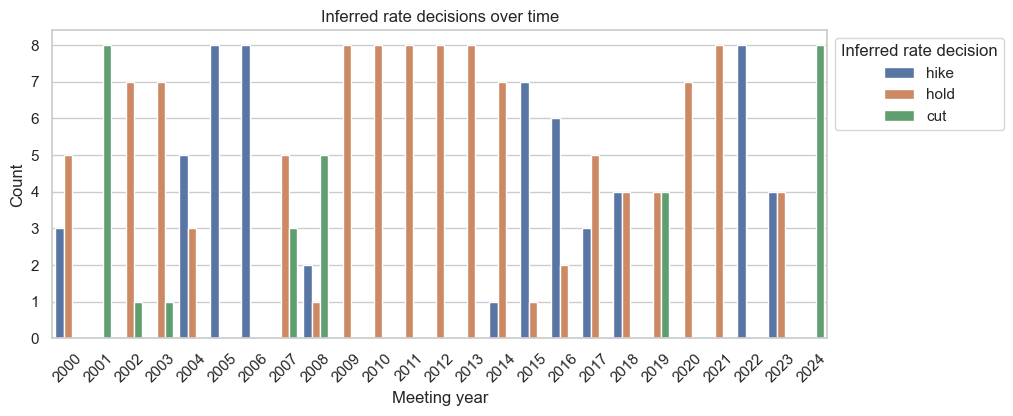

In [87]:
RATE_PATTERNS = {
    "hike": [
        r"\b(decided|voted|agreed|approved)\b.{0,80}\b(raise|raising|increase|increasing)\b.{0,80}\b(target|federal funds|discount rate)\b",
        r"\b(raise|raising|increase|increasing|increased)\b.{0,80}\b(target range|target for the federal funds rate|federal funds rate)\b",
    ],
    "cut": [
        r"\b(decided|voted|agreed|approved)\b.{0,80}\b(lower|lowering|reduce|reducing|decrease|decreasing|cut)\b.{0,80}\b(target|federal funds|discount rate)\b",
        r"\b(lower|lowering|reduce|reducing|decrease|decreasing|cut)\b.{0,80}\b(target range|target for the federal funds rate|federal funds rate)\b",
    ],
    "hold": [
        r"\b(decided|voted|agreed)\b.{0,80}\b(maintain|keep|leave)\b.{0,80}\b(target range|target for the federal funds rate|federal funds rate)\b",
        r"\b(will|would|shall|to)\b.{0,20}\b(maintain|keep|leave)\b.{0,80}\b(target range|target for the federal funds rate|federal funds rate)\b",
        r"\b(maintain|maintaining|keep|keeping|kept|leave|leaving)\b.{0,80}\b(target range|target for the federal funds rate|federal funds rate)\b",
        r"\b(target range|target for the federal funds rate|federal funds rate)\b.{0,80}\b(unchanged|maintained)\b",
    ],
}

def infer_rate_decision(text):
    text = clean_text(text)
    for label in ["hike", "cut", "hold"]:
        if any(re.search(pattern, text, flags=re.DOTALL) for pattern in RATE_PATTERNS[label]):
            return label
    return "unknown"

df = df.assign(rate_decision=df["statement_text"].map(infer_rate_decision))
display(df["rate_decision"].value_counts(dropna=False))

fig, ax = plt.subplots(figsize=(10, 4))
sns.countplot(data=df, x="year", hue="rate_decision", ax=ax)
ax.set_title("Inferred rate decisions over time")
ax.set_xlabel("Meeting year")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Inferred rate decision", loc="upper left", bbox_to_anchor=(1, 1))

## 4. Inflation vs marché du travail

Angle principal : quelle place la Fed donne à l'inflation et au marché du travail ?

In [88]:
INFLATION_TERMS = [
    "inflation", "inflationary", "prices", "price stability", "price pressures",
    "inflation expectations", "core inflation", "pce inflation", "consumer prices",
    "energy prices", "food prices", "disinflation",
]

LABOR_TERMS = [
    "employment", "unemployment", "labor market", "job gains", "payrolls",
    "hiring", "layoffs", "wages", "labor demand", "labor supply",
    "labor force", "slack",
]

pd.DataFrame({
    "inflation": pd.Series(INFLATION_TERMS),
    "labor": pd.Series(LABOR_TERMS),
})

,inflation,labor
0,inflation,employment
1,inflationary,unemployment
2,prices,labor market
3,price stability,job gains
4,price pressures,payrolls
5,inflation expectations,hiring
6,core inflation,layoffs
7,pce inflation,wages
8,consumer prices,labor demand
9,energy prices,labor supply


In [89]:
def count_terms(text, terms):
    text = clean_text(text)
    total = 0
    for term in terms:
        pattern = re.escape(term.lower()).replace(r"\ ", r"\s+")
        total += len(re.findall(rf"\b{pattern}\b", text))
    return total


def add_topic_score(data, corpus, topic, terms):
    text_col = f"{corpus}_clean_text"
    n_col = f"{corpus}_n_words"
    count_col = f"{corpus}_{topic}_count"
    freq_col = f"{corpus}_{topic}_per_1000"

    counts = data[text_col].map(lambda text: count_terms(text, terms))

    return data.assign(**{
        count_col: counts,
        freq_col: lambda x: 1_000 * x[count_col] / x[n_col].replace(0, np.nan),
    })


def period_label(date):
    date = pd.Timestamp(date)
    if pd.Timestamp("2001-03-01") <= date <= pd.Timestamp("2001-11-30"):
        return "2001 recession"
    if pd.Timestamp("2007-12-01") <= date <= pd.Timestamp("2009-06-30"):
        return "GFC"
    if pd.Timestamp("2020-02-01") <= date <= pd.Timestamp("2020-06-30"):
        return "Covid shock"
    if pd.Timestamp("2021-01-01") <= date <= pd.Timestamp("2024-12-31"):
        return "post-Covid inflation"
    return "other"


PERIOD_ORDER = ["2001 recession", "GFC", "Covid shock", "post-Covid inflation", "other"]

df = (
    df.sort_values("date")
    .reset_index(drop=True)
    .pipe(add_topic_score, "statement", "inflation", INFLATION_TERMS)
    .pipe(add_topic_score, "statement", "labor", LABOR_TERMS)
    .pipe(add_topic_score, "minutes", "inflation", INFLATION_TERMS)
    .pipe(add_topic_score, "minutes", "labor", LABOR_TERMS)
    .assign(
        statement_balance=lambda x: x["statement_inflation_per_1000"] - x["statement_labor_per_1000"],
        minutes_balance=lambda x: x["minutes_inflation_per_1000"] - x["minutes_labor_per_1000"],
        period=lambda x: x["date"].map(period_label),
        next_rate_decision=lambda x: x["rate_decision"].shift(-1),
    )
    .assign(
        minutes_minus_statement_balance=lambda x: x["minutes_balance"] - x["statement_balance"],
        period=lambda x: pd.Categorical(x["period"], categories=PERIOD_ORDER, ordered=True),
    )
)

topic_long = (
    df.loc[:, [
        "date", "year", "period", "rate_decision", "next_rate_decision",
        "statement_inflation_per_1000", "statement_labor_per_1000",
        "minutes_inflation_per_1000", "minutes_labor_per_1000",
    ]]
    .melt(
        id_vars=["date", "year", "period", "rate_decision", "next_rate_decision"],
        var_name="measure",
        value_name="mentions_per_1000",
    )
    .assign(
        document_type=lambda x: x["measure"].str.extract(r"^(statement|minutes)"),
        topic=lambda x: x["measure"].str.extract(r"_(inflation|labor)_"),
    )
    .drop(columns="measure")
)

topic_long.head()

,date,year,period,rate_decision,next_rate_decision,mentions_per_1000,document_type,topic
0,2000-02-02,2000,other,hike,hike,14.851485,statement,inflation
1,2000-03-21,2000,other,hike,hike,14.423077,statement,inflation
2,2000-05-16,2000,other,hike,hold,14.851485,statement,inflation
3,2000-06-28,2000,other,hold,hold,22.471910,statement,inflation
4,2000-08-22,2000,other,hold,hold,16.574586,statement,inflation


Premier repère : mentions moyennes pour 1 000 mots.

In [90]:
(
    topic_long
    .groupby(["document_type", "topic"], observed=True)["mentions_per_1000"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

count   mean  median   std
document_type topic                                
minutes       inflation    199  13.84   13.22  4.73
              labor        199   5.57    5.51  2.45
statement     inflation    199  19.96   21.11  7.62
              labor        199   7.75    8.25  5.90

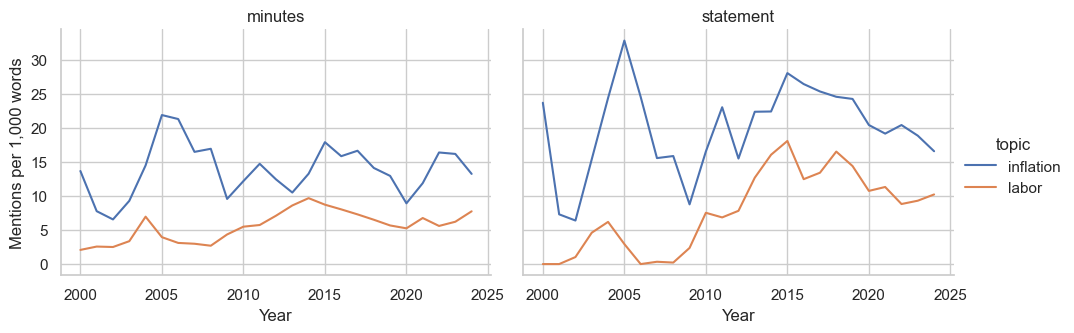

In [91]:
yearly_topics = (
    topic_long
    .groupby(["year", "document_type", "topic"], observed=True, as_index=False)["mentions_per_1000"]
    .mean()
)

g = sns.relplot(
    data=yearly_topics,
    x="year",
    y="mentions_per_1000",
    hue="topic",
    col="document_type",
    kind="line",
    height=3.5,
    aspect=1.4,
)
g.set_axis_labels("Year", "Mentions per 1,000 words")
g.set_titles("{col_name}");

L'inflation domine dans les deux corpus. Par 1 000 mots, les Statements sont plus concentrés que les Minutes sur les deux thèmes.

Score de balance : mentions d'inflation moins mentions du marché du travail, pour 1 000 mots.

Positif : le document parle davantage d'inflation.

In [92]:
balance_long = (
    df.loc[:, [
        "date", "year", "period", "rate_decision", "next_rate_decision",
        "statement_balance", "minutes_balance",
    ]]
    .melt(
        id_vars=["date", "year", "period", "rate_decision", "next_rate_decision"],
        value_vars=["statement_balance", "minutes_balance"],
        var_name="document_type",
        value_name="balance_per_1000",
    )
    .assign(document_type=lambda x: x["document_type"].str.replace("_balance", "", regex=False))
)

(
    balance_long
    .groupby("document_type", observed=True)["balance_per_1000"]
    .describe()
    .round(2)
)

,count,mean,std,min,25%,50%,75%,max
document_type,,,,,,,,
minutes,199.0,8.27,5.07,-1.11,4.58,7.12,10.49,24.02
statement,199.0,12.21,7.61,-1.45,7.60,10.37,14.56,42.02


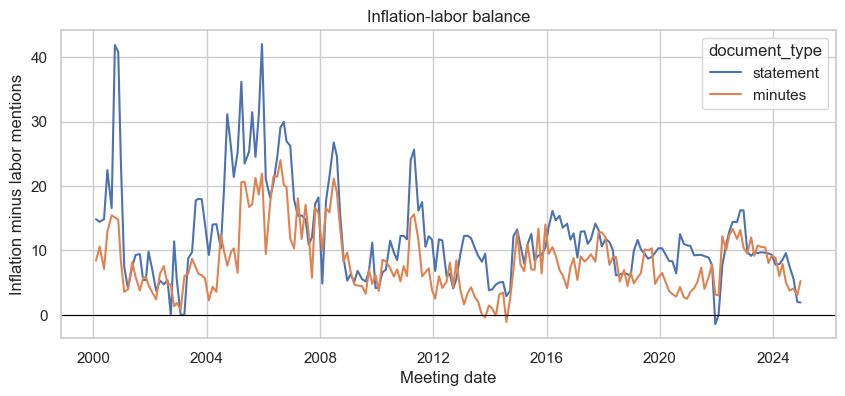

In [93]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=balance_long, x="date", y="balance_per_1000", hue="document_type", ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Inflation-labor balance")
ax.set_xlabel("Meeting date")
ax.set_ylabel("Inflation minus labor mentions");

Le score reste souvent positif : le vocabulaire d'inflation prend plus de place que celui du marché du travail.

Les dates où les deux formats divergent le plus.

In [94]:
(
    df.assign(abs_gap=lambda x: x["minutes_minus_statement_balance"].abs())
    .nlargest(12, "abs_gap")
    .loc[:, [
        "date", "period", "rate_decision", "next_rate_decision",
        "statement_balance", "minutes_balance", "minutes_minus_statement_balance",
    ]]
    .round(2)
)

/var/folders/_y/c59kgpv93ss_5wq08r4ljvrc0000gn/T/ipykernel_67695/3427125880.py:8: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(2)


,date,period,rate_decision,next_rate_decision,statement_balance,minutes_balance,minutes_minus_statement_balance
5,2000-10-03,other,hold,hold,41.88,15.13,-26.76
6,2000-11-15,other,hold,hold,40.82,14.78,-26.04
37,2004-09-21,other,hike,hike,31.14,7.63,-23.51
47,2005-12-13,other,hike,hike,42.02,21.92,-20.09
40,2005-02-02,other,hike,hike,25.27,6.53,-18.74
38,2004-11-10,other,hike,hike,25.83,9.81,-16.02
41,2005-03-22,other,hike,hike,36.18,20.63,-15.56
7,2000-12-19,other,hold,cut,23.81,8.37,-15.44
55,2006-12-12,other,hike,hold,26.25,11.85,-14.40
44,2005-08-09,other,hike,hike,31.47,17.17,-14.30


Lien rapide avec les décisions de taux.

Pour la corrélation, je code `cut=-1`, `hold=0`, `hike=1`.

In [95]:
DECISION_CODE = {"cut": -1, "hold": 0, "hike": 1}

df = df.assign(
    rate_decision_code=lambda x: x["rate_decision"].map(DECISION_CODE),
    next_rate_decision_code=lambda x: x["next_rate_decision"].map(DECISION_CODE),
)

(
    df.loc[:, [
        "statement_balance", "minutes_balance",
        "rate_decision_code", "next_rate_decision_code",
    ]]
    .corr()
    .loc[["statement_balance", "minutes_balance"], ["rate_decision_code", "next_rate_decision_code"]]
    .round(2)
)

,rate_decision_code,next_rate_decision_code
statement_balance,0.38,0.35
minutes_balance,0.38,0.31


La corrélation est positive avec la décision courante et avec la décision suivante. Les réunions plus orientées inflation sont plus souvent proches de hausses de taux.

In [96]:
(
    balance_long
    .groupby(["document_type", "rate_decision"], observed=True)["balance_per_1000"]
    .agg(["count", "mean", "median"])
    .round(2)
)

count   mean  median
document_type rate_decision                      
minutes       cut               30   7.65    5.95
              hike              59  12.18   10.57
              hold             110   6.35    5.92
statement     cut               30   9.10    8.82
              hike              59  16.96   14.42
              hold             110  10.51    9.66

In [97]:
(
    balance_long
    .dropna(subset=["next_rate_decision"])
    .groupby(["document_type", "next_rate_decision"], observed=True)["balance_per_1000"]
    .agg(["count", "mean", "median"])
    .round(2)
)

count   mean  median
document_type next_rate_decision                      
minutes       cut                    30   8.01    7.20
              hike                   58  11.67   10.46
              hold                  110   6.58    6.01
statement     cut                    30   9.41    8.84
              hike                   58  16.64   14.28
              hold                  110  10.73    9.75

Les périodes sont des repères simples. Suffisant pour une première lecture.

In [98]:
(
    topic_long
    .groupby(["period", "document_type", "topic"], observed=True)["mentions_per_1000"]
    .mean()
    .unstack("topic")
    .round(2)
)

topic                               inflation  labor
period               document_type                  
2001 recession       minutes             8.30   2.73
                     statement           6.86   0.00
GFC                  minutes            14.42   2.86
                     statement          13.65   0.78
Covid shock          minutes             8.11   4.67
                     statement          16.68   8.34
post-Covid inflation minutes            14.43   6.59
                     statement          18.77   9.93
other                minutes            13.97   5.71
                     statement          21.37   8.20

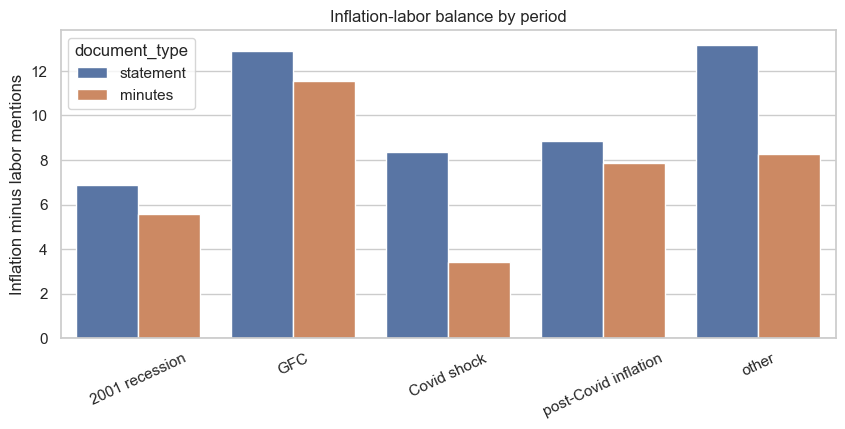

In [99]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(
    data=balance_long,
    x="period",
    y="balance_per_1000",
    hue="document_type",
    errorbar=None,
    ax=ax,
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Inflation-labor balance by period")
ax.set_xlabel("")
ax.set_ylabel("Inflation minus labor mentions")
ax.tick_params(axis="x", rotation=25);

Covid ressort différemment : le marché du travail devient beaucoup plus visible dans les Statements que dans les crises précédentes.

Notes pour la prochaine lecture :

- relire les dates avec les plus gros écarts ;
- voir si les Minutes sont seulement plus détaillées ou vraiment orientées différemment ;
- comparer ensuite cette lecture par dictionnaire avec TF-IDF et embeddings.